In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/watson_healthcare_modified.csv')
print(" Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

 Dataset loaded successfully!
Shape: (1676, 35)


,EmployeeID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1313919,41,No,Travel_Rarely,1102,Cardiology,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,1200302,49,No,Travel_Frequently,279,Maternity,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,1060315,37,Yes,Travel_Rarely,1373,Maternity,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,1272912,33,No,Travel_Frequently,1392,Maternity,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,1414939,27,No,Travel_Rarely,591,Maternity,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
jobrole_groups = {
    'Nurse': 'Clinical', 'Doctor': 'Clinical', 'Surgeon': 'Clinical',
    'Lab Technician': 'Technical', 'Technician': 'Technical',
    'Healthcare Representative': 'Technical',
    'Manager': 'Administrative', 'HR': 'Administrative',
    'Clerk': 'Administrative', 'Sales Executive': 'Administrative',
    'Research Director': 'Administrative'
}

df['JobRoleGroup'] = df['JobRole'].map(jobrole_groups).fillna('Other')

df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

In [ ]:
selected_features = [
   'OverTime', 'JobRoleGroup', 'Department', 'DistanceFromHome',
    'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
    'RelationshipSatisfaction', 'JobInvolvement', 'TrainingTimesLastYear',
    'YearsSinceLastPromotion', 'YearsInCurrentRole', 'TotalWorkingYears',
    'JobLevel', 'MonthlyIncome', 'PercentSalaryHike', 'PerformanceRating',
    'YearsWithCurrManager'
]
df = df[selected_features].copy()
print("\nSelected features for feature extraction:")
print(df.head())


Selected features for feature extraction:
   OverTime JobRoleGroup  Department  DistanceFromHome  JobSatisfaction  \
0         1     Clinical  Cardiology                 1                4   
1         0        Other   Maternity                 8                2   
2         1     Clinical   Maternity                 2                3   
3         1        Other   Maternity                 3                3   
4         0     Clinical   Maternity                 2                2   

   EnvironmentSatisfaction  WorkLifeBalance  RelationshipSatisfaction  \
0                        2                1                         1   
1                        3                3                         4   
2                        4                3                         2   
3                        4                3                         3   
4                        1                3                         4   

   JobInvolvement  TrainingTimesLastYear  YearsSinceLastPromotion  

In [ ]:
numeric_features = [
    'DistanceFromHome', 'JobSatisfaction', 'EnvironmentSatisfaction',
    'WorkLifeBalance', 'RelationshipSatisfaction', 'JobInvolvement',
    'TrainingTimesLastYear', 'YearsSinceLastPromotion', 'YearsInCurrentRole',
    'TotalWorkingYears', 'JobLevel', 'MonthlyIncome', 'PercentSalaryHike',
    'PerformanceRating', 'YearsWithCurrManager',
]
categorical_features = ['Department', 'JobRoleGroup']

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),    # handle missing numbers
    ('scaler', MinMaxScaler())                        # scale to 0–1 range
])
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))  # one-hot encode text columns
])

feature_extraction_pipeline = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
])
remainder='passthrough'

print("\n✅ Feature extraction pipeline created successfully!")


✅ Feature extraction pipeline created successfully!


In [ ]:
# Apply pipeline
X_prepared = feature_extraction_pipeline.fit_transform(df)

# Get feature names
encoded_columns = feature_extraction_pipeline.get_feature_names_out().tolist()

# Rename remainder → OverTime
encoded_columns[-1] = 'OverTime'


clean_df = pd.DataFrame(X_prepared, columns=encoded_columns)


print(clean_df.head())
print("OverTime present? →", 'OverTime' in clean_df.columns)


   num__DistanceFromHome  num__JobSatisfaction  num__EnvironmentSatisfaction  \
0               0.000000              1.000000                      0.333333   
1               0.250000              0.333333                      0.666667   
2               0.035714              0.666667                      1.000000   
3               0.071429              0.666667                      1.000000   
4               0.035714              0.333333                      0.000000   

   num__WorkLifeBalance  num__RelationshipSatisfaction  num__JobInvolvement  \
0              0.000000                       0.000000             0.666667   
1              0.666667                       1.000000             0.333333   
2              0.666667                       0.333333             0.333333   
3              0.666667                       0.666667             0.666667   
4              0.666667                       1.000000             0.666667   

   num__TrainingTimesLastYear  num__YearsSin

In [ ]:
for col in clean_df.select_dtypes(include=[np.number]):
    q1, q3 = clean_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    clean_df[col] = clean_df[col].clip(lower, upper)

In [ ]:
output_path = '/content/clean_retention_features_updated_new.csv'
clean_df.to_csv(output_path, index=False)
print(f"\n✅ Cleaned dataset saved to: {output_path}")
print("Shape:", df.shape)


✅ Cleaned dataset saved to: /content/clean_retention_features_updated_new.csv
Shape: (1676, 18)


In [ ]:
from google.colab import files
files.download('/content/clean_retention_features_updated_new.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/clean_retention_features_updated_new.csv')
print(" Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

 Dataset loaded successfully!
Shape: (1676, 20)


,num__DistanceFromHome,num__JobSatisfaction,num__EnvironmentSatisfaction,num__WorkLifeBalance,num__RelationshipSatisfaction,num__JobInvolvement,num__TrainingTimesLastYear,num__YearsSinceLastPromotion,num__YearsInCurrentRole,num__TotalWorkingYears,num__JobLevel,num__MonthlyIncome,num__PercentSalaryHike,num__PerformanceRating,num__YearsWithCurrManager,cat__Department_Cardiology,cat__Department_Maternity,cat__Department_Neurology,cat__JobRoleGroup_Clinical,OverTime
0,0.000000,1.000000,0.333333,0.000000,0.000000,0.666667,0.083333,0.000000,0.222222,0.200,0.25,0.262454,0.000000,0.0,0.294118,1.0,0.0,0.0,1.0,0.0
1,0.250000,0.333333,0.666667,0.666667,1.000000,0.333333,0.500000,0.066667,0.388889,0.250,0.25,0.217009,0.857143,0.0,0.411765,0.0,1.0,0.0,0.0,1.0
2,0.035714,0.666667,1.000000,0.666667,0.333333,0.333333,0.500000,0.000000,0.000000,0.175,0.00,0.056925,0.285714,0.0,0.000000,0.0,1.0,0.0,1.0,0.0
3,0.071429,0.666667,1.000000,0.666667,0.666667,0.666667,0.500000,0.200000,0.388889,0.200,0.00,0.100053,0.000000,0.0,0.000000,0.0,1.0,0.0,0.0,1.0
4,0.035714,0.333333,0.000000,0.666667,1.000000,0.666667,0.500000,0.133333,0.111111,0.150,0.00,0.129489,0.071429,0.0,0.117647,0.0,1.0,0.0,1.0,0.0


In [ ]:
print("Features available:", clean_df.columns.tolist())

Features available: ['num__DistanceFromHome', 'num__JobSatisfaction', 'num__EnvironmentSatisfaction', 'num__WorkLifeBalance', 'num__RelationshipSatisfaction', 'num__JobInvolvement', 'num__TrainingTimesLastYear', 'num__YearsSinceLastPromotion', 'num__YearsInCurrentRole', 'num__TotalWorkingYears', 'num__JobLevel', 'num__MonthlyIncome', 'num__PercentSalaryHike', 'num__PerformanceRating', 'num__YearsWithCurrManager', 'cat__Department_Cardiology', 'cat__Department_Maternity', 'cat__Department_Neurology', 'cat__JobRoleGroup_Clinical', 'OverTime']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [ ]:
clustering_features = [
    'OverTime', 'WorkLifeBalance', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'RelationshipSatisfaction',
    'JobInvolvement', 'TrainingTimesLastYear',
    'YearsSinceLastPromotion', 'YearsInCurrentRole',
    'TotalWorkingYears', 'JobLevel', 'MonthlyIncome',
    'PercentSalaryHike', 'PerformanceRating',
    'YearsWithCurrManager','DistanceFromHome'
]
available_features = [f for f in clustering_features if f in clean_df.columns]
X_cluster = clean_df[available_features].copy()

print(f"Using {len(available_features)} features for clustering:")
print(available_features)


Using 1 features for clustering:
['OverTime']


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:

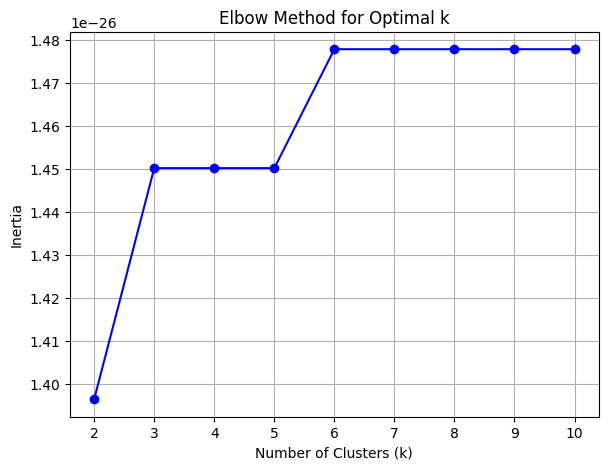

In [ ]:

def find_optimal_clusters(X, max_k=10):

    inertias = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

    # Plot Elbow Method
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(k_range, inertias, 'bo-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)


# Find optimal clusters
optimal_k = find_optimal_clusters(X_cluster)